# Phase A — Evidence & Decision Basis

CRISP-DM *Data Understanding*. Goal: predict **Hit vs Flop** *before release* from Genre, Platform and
Publisher reputation. Every decision below is grounded in the data, no arbitrary numbers. Target axis =
**sales only** (year-based percentile).

In [1]:
%matplotlib inline
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
pd.set_option('display.width', 200)

RAW = "data/raw/Video Games Sales (1980-2024) - Raw.csv"
df = pd.read_csv(RAW)
df['year'] = pd.to_datetime(df['release_date'], format='%d-%m-%Y', errors='coerce').dt.year

# Collapse 81 raw consoles -> platform families (PS1/2/3 -> PlayStation, etc.)
FAM = {}
for x in ['PS','PS2','PS3','PS4','PS5','PSP','PSV','PSN']: FAM[x] = 'PlayStation'
for x in ['XB','X360','XOne','XS','XBL']:                  FAM[x] = 'Xbox'
for x in ['NS','Wii','WiiU','DS','DSi','DSiW','3DS','GB','GBC','GBA','SNES','NES','N64','GC','VB','VC','FDS','iQue']:
    FAM[x] = 'Nintendo'
for x in ['PC','OSX','Linux']:                            FAM[x] = 'PC'
df['platform_family'] = df['console'].map(FAM).fillna('Other')   # orphan/legacy consoles -> Other

# Fold very small genres (<=30 rows) into the dataset's own catch-all 'Misc'
SMALL_GENRES = ['Education', 'Board Game', 'Sandbox', 'Party', 'MMO']
df['genre'] = df['genre'].replace(SMALL_GENRES, 'Misc')

print(f"Raw rows: {len(df):,} | columns: {df.shape[1]} | genres: {df['genre'].nunique()} "
      f"(small folded into Misc) | consoles: {df['console'].nunique()} -> platform families: {df['platform_family'].nunique()}")

Raw rows: 64,016 | columns: 16 | genres: 15 (small folded into Misc) | consoles: 81 -> platform families: 5


## 1. Data Overview

In [2]:
roles = {
 'img':'dropped (image path)', 'title':'ID / de-duplication', 'console':'-> Platform_Family (feature)',
 'genre':'feature', 'publisher':'-> Publisher_Tier (feature)', 'developer':'not used (61% Unknown)',
 'critic_score':'not used (dropped target axis)', 'total_sales':'TARGET (defines Hit)',
 'na_sales':'not used (= total component)', 'jp_sales':'not used (= total component)',
 'pal_sales':'not used (= total component)', 'other_sales':'not used (= total component)',
 'release_date':'-> year (scope)', 'last_update':'not used'}
overview = pd.DataFrame({'dtype': df.dtypes.astype(str),
                         'non_null_%': (df.notna().mean()*100).round(1),
                         'n_unique': df.nunique(),
                         'role': pd.Series(roles)})
display(overview)

,dtype,non_null_%,n_unique,role
console,object,100.0,81,-> Platform_Family (feature)
critic_score,float64,10.4,89,not used (dropped target axis)
developer,object,100.0,8862,not used (61% Unknown)
genre,object,100.0,15,feature
img,object,100.0,56177,dropped (image path)
jp_sales,float64,10.5,121,not used (= total component)
last_update,object,27.9,1545,not used
na_sales,float64,19.7,320,not used (= total component)
other_sales,float64,23.6,133,not used (= total component)
pal_sales,float64,20.0,256,not used (= total component)


In [3]:
# Label availability: why sales-only? (sales is far better covered than score)
hs, hc, n = df['total_sales'].notna(), df['critic_score'].notna(), len(df)
avail = pd.DataFrame({
 'group':['sales only','score only','both','neither','>> HAS SALES (any)','>> has score (any)'],
 'rows':[(hs&~hc).sum(),(~hs&hc).sum(),(hs&hc).sum(),(~hs&~hc).sum(),hs.sum(),hc.sum()]})
avail['%_of_all'] = (avail['rows']/n*100).round(1)
display(avail)
print(f"Sales coverage {hs.mean()*100:.1f}%  vs  score {hc.mean()*100:.1f}%  ->  "
      f"sales-only keeps ~{hs.sum()/hc.sum():.1f}x more labelable rows.")

,group,rows,%_of_all
0,sales only,14796,23.1
1,score only,2552,4.0
2,both,4126,6.4
3,neither,42542,66.5
4,>> HAS SALES (any),18922,29.6
5,>> has score (any),6678,10.4


Sales coverage 29.6%  vs  score 10.4%  ->  sales-only keeps ~2.8x more labelable rows.


## 2. Target — `Hit = year-based top-X% sales`

Relative to the **release year** (fair across a growing market). Compared at **X = 20% vs 30%** (this
doubles as the sensitivity check). Industry corroboration: the million-seller / *Greatest Hits* badge.

,definition,usable_rows,Hit,Flop,hit_rate
0,year top 20%,17102,3480,13622,0.203
1,year top 30%,17102,5194,11908,0.304


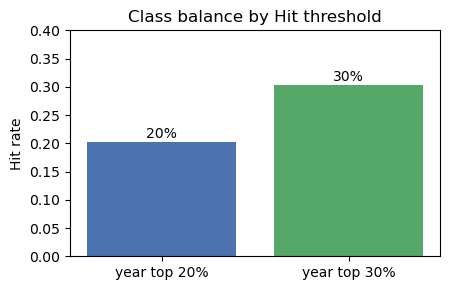

In [4]:
d = df[(df['year'].between(2000,2018)) & df['total_sales'].notna()].copy()
rows = []
for q in [0.20, 0.30]:
    thr = d.groupby('year')['total_sales'].transform(lambda s: s.quantile(1-q))
    hit = (d['total_sales'] >= thr).astype(int)
    rows.append({'definition':f'year top {int(q*100)}%', 'usable_rows':len(d),
                 'Hit':int(hit.sum()), 'Flop':int((1-hit).sum()), 'hit_rate':round(hit.mean(),3)})
hit_tbl = pd.DataFrame(rows); display(hit_tbl)

fig, ax = plt.subplots(figsize=(4.6,3))
ax.bar(hit_tbl['definition'], hit_tbl['hit_rate'], color=['#4C72B0','#55A868'])
for i,v in enumerate(hit_tbl['hit_rate']): ax.text(i, v+0.006, f'{v:.0%}', ha='center')
ax.set_ylabel('Hit rate'); ax.set_ylim(0,0.4); ax.set_title('Class balance by Hit threshold')
plt.tight_layout(); plt.savefig('evidence/figures/a_hit_rate_threshold.png', dpi=110); plt.show()

## 3. Scope - cap at ≤ 2018, compare *2000+* vs *all data*

Post-2018 is essentially empty (data quality) → hard cap. Pre-2000 sits on legacy platforms → kept as a
separate **no-cutoff** scope so Phase C can empirically justify the 2000 cutoff (scored on identical test rows).

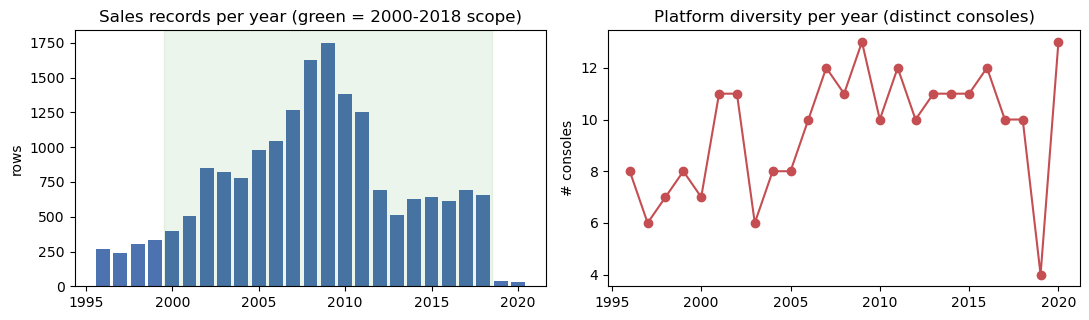

post-2018 sales rows: 63 (2021+: 0)  ->  <=2018 cap is forced
pre-2000 sales rows : 1667 on legacy platforms  ->  'no-cutoff' comparison scope


In [5]:
sd = df[df['total_sales'].notna() & df['year'].notna()]
py = sd.groupby('year').agg(rows=('title','size'), consoles=('console','nunique'))
py = py[(py.index>=1996) & (py.index<=2021)]

fig, ax = plt.subplots(1, 2, figsize=(11,3.3))
ax[0].bar(py.index, py['rows'], color='#4C72B0'); ax[0].axvspan(1999.5,2018.5,color='green',alpha=0.08)
ax[0].set_title('Sales records per year (green = 2000-2018 scope)'); ax[0].set_ylabel('rows')
ax[1].plot(py.index, py['consoles'], marker='o', color='#C44E52')
ax[1].set_title('Platform diversity per year (distinct consoles)'); ax[1].set_ylabel('# consoles')
plt.tight_layout(); plt.savefig('evidence/figures/a_scope_evidence.png', dpi=110); plt.show()

print(f"post-2018 sales rows: {int((sd['year']>2018).sum())} (2021+: 0)  ->  <=2018 cap is forced")
print(f"pre-2000 sales rows : {int((sd['year']<2000).sum())} on legacy platforms  ->  'no-cutoff' comparison scope")

## 4. Features & Publisher Tier

`Platform_Family` collapses 81 consoles into families (orphan/legacy → *Other*). Small genres folded into
*Misc*. `Publisher_Tier` = how many **million-seller** games a publisher has (iconic ≥ 1.0M — the Nintendo
*Player's Choice* 1M threshold, [ref](https://niwanetwork.org/wiki/Player%27s_Choice)).

> **EDA only here** this section *justifies the tier design* on full data. The real leakage-safe
> `Publisher_Tier` (counts from **train only**, test via lookup, unseen publisher → tier 0) is built in **Phase B**.

In [6]:
fam = d['platform_family'].value_counts().rename_axis('platform_family').reset_index(name='rows')
display(fam)
print(f"Feature dimensionality -> genres: {d['genre'].nunique()} | platform families: {d['platform_family'].nunique()}")

,platform_family,rows
0,PlayStation,6718
1,Nintendo,6189
2,Xbox,2662
3,PC,1493
4,Other,40


Feature dimensionality -> genres: 15 | platform families: 5


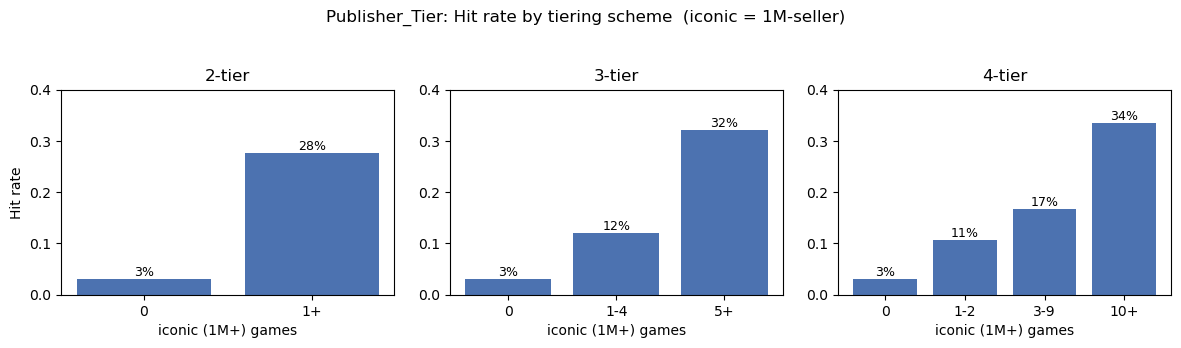

,rows,hit_rate,publishers
tier,,,
0,5050,0.030,555
1-4,2706,0.121,43
5+,9346,0.321,32


In [7]:
# Primary target = year top 20%
thr = d.groupby('year')['total_sales'].transform(lambda s: s.quantile(0.80))
d['hit'] = (d['total_sales'] >= thr).astype(int)

# iconic = million-seller (>=1.0M); count per publisher, de-duplicated by (title, publisher)
uniq = d.drop_duplicates(['title','publisher']).assign(ic=lambda x: (x['total_sales']>=1.0).astype(int))
icount = uniq.groupby('publisher')['ic'].sum()
d['iconic_count'] = d['publisher'].map(icount).fillna(0).astype(int)

def tmap(n, s):
    if s == 2: return '0' if n==0 else '1+'
    if s == 3: return '0' if n==0 else ('1-4' if n<=4 else '5+')
    if n==0: return '0'
    if n<=2: return '1-2'
    if n<=9: return '3-9'
    return '10+'

order = {2:['0','1+'], 3:['0','1-4','5+'], 4:['0','1-2','3-9','10+']}
fig, ax = plt.subplots(1, 3, figsize=(12,3.3))
for j, s in enumerate([2,3,4]):
    col = f't{s}'; d[col] = d['iconic_count'].apply(lambda n: tmap(n,s))
    g = d.groupby(col)['hit'].mean().reindex(order[s])
    ax[j].bar(range(len(g)), g.values, color='#4C72B0')
    ax[j].set_xticks(range(len(g))); ax[j].set_xticklabels(g.index)
    for i,v in enumerate(g.values): ax[j].text(i, v+0.006, f'{v:.0%}', ha='center', fontsize=9)
    ax[j].set_title(f'{s}-tier'); ax[j].set_ylim(0,0.4); ax[j].set_xlabel('iconic (1M+) games')
ax[0].set_ylabel('Hit rate')
plt.suptitle('Publisher_Tier: Hit rate by tiering scheme  (iconic = 1M-seller)', y=1.04)
plt.tight_layout(); plt.savefig('evidence/figures/a_tier_hit_rate.png', dpi=110, bbox_inches='tight'); plt.show()

# Chosen scheme = 3-tier (clean monotonic + adequate group sizes)
d['tier'] = d['iconic_count'].apply(lambda n: tmap(n,3))
display(d.groupby('tier').agg(rows=('hit','size'), hit_rate=('hit','mean'),
                              publishers=('publisher','nunique')).reindex(['0','1-4','5+']).round(3))

## 5. Locked decisions (Phase A)

| Area | Decision | Basis |
|---|---|---|
| **Target** | `Hit = year-based top-20%` sales (20% vs 30% compared in C) | relative fairness across years + 1M-seller anchor + sensitivity sweep |
| **Scope** | 2000–2018 primary; **all ≤2018** as a no-cutoff comparison | post-2018 empty; pre-2000 legacy platforms; fair same-test-row comparison |
| **Features** | Genre (15) · Platform_Family (5) · Publisher_Tier (3) | all known pre-release; established success determinants |
| **Publisher_Tier** | 3 tiers by million-seller count: `0 / 1–4 / 5+` | clean monotonic hit-rate (~3% / 12% / 32%), adequate group sizes |
| **Cleaning** | small genres → *Misc*; orphan consoles → *Other* | too sparse to be their own one-hot column |

## 6. Phase A output — usable data & feature dimensions

In [8]:
sales = df[df['total_sales'].notna() & df['year'].notna()]
scope_2000 = sales[sales['year'].between(2000,2018)]
scope_all  = sales[sales['year'] <= 2018]

print("USABLE ROWS (sales present + parseable year):")
print(f"  scope_2000_2018  (primary)        : {len(scope_2000):,}")
print(f"  scope_all  (<=2018, incl. pre-2000): {len(scope_all):,}")
print()
print("FEATURE DIMENSIONS (categorical, all pre-release):")
print(f"  genre            : {scope_2000['genre'].nunique():>2} categories  (small genres folded into 'Misc')")
print(f"  platform_family  : {scope_2000['platform_family'].nunique():>2} categories  (PlayStation / Xbox / Nintendo / PC / Other)")
print(f"  publisher_tier   :  3 categories  (0 / 1-4 / 5+ million-seller games)")
print()
print("TARGET — class balance (year-based percentile):")
for q in [0.20, 0.30]:
    thr = scope_2000.groupby('year')['total_sales'].transform(lambda s: s.quantile(1-q))
    hr = (scope_2000['total_sales'] >= thr).mean()
    print(f"  top {int(q*100)}%   ->  Hit {hr:5.1%}  /  Flop {1-hr:5.1%}")

USABLE ROWS (sales present + parseable year):
  scope_2000_2018  (primary)        : 17,102
  scope_all  (<=2018, incl. pre-2000): 18,769

FEATURE DIMENSIONS (categorical, all pre-release):
  genre            : 15 categories  (small genres folded into 'Misc')
  platform_family  :  5 categories  (PlayStation / Xbox / Nintendo / PC / Other)
  publisher_tier   :  3 categories  (0 / 1-4 / 5+ million-seller games)

TARGET — class balance (year-based percentile):
  top 20%   ->  Hit 20.3%  /  Flop 79.7%
  top 30%   ->  Hit 30.4%  /  Flop 69.6%
